# 23 - Critical stations through several lenses

We have several ways to call a station critical, and we want to see whether they actually identify the same places. A cut vertex measures disconnection, betweenness measures shortest-path brokerage, weighted degree measures scheduled service volume, walking distance measures local substitutability, and the later experiments add population weighting, peak-hour structure, and closure-time cost.

The question we are trying to answer is: **which stations stay near the top under several different definitions, and which ones only look critical because of one particular metric?**

We use notebook 04's station metrics as the required 30,463-station backbone. The other inputs are loaded when available:

- articulation points and graph edges from notebooks 03 and 02;
- walking-alternative distances from notebook 05;
- demand-weighted ranks from notebook 21;
- peak-window centrality from notebooks 20 and 19;
- closure-cost results from notebook 22;
- multimodal counts from notebook 17 as context only.

We convert each usable measure to a common direction—higher means more critical—then compare ranks with Spearman correlation and top-50 overlap. We save the long lens table, pairwise agreement, coverage, per-station profiles, a 40-row shortlist, lens-specific flags, a compact JSON summary, and six figures under `outputs/nb/23_critical_station_lenses/`.

The main thing we need to remember is that coverage differs sharply. Some lenses score the whole network, articulation severity only exists for cut vertices, the walking lens starts from a preselected top-decile set, and the closure model evaluates only 30 candidates. Missing from a lens means “not evaluated,” not a zero score.

## 1. Set up the repository paths

We locate the project, switch into it, and create the shared `outputs/nb` folder. The helper installs only missing packages and can clone the project in Colab. Every path below comes from the `REPO`, `DATA`, and `OUT` values set here.

In [1]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

print(f"Python {sys.version.split()[0]} -> {sys.executable}")

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        print("Installing missing packages:", ", ".join(missing))
        print("Using interpreter:", sys.executable)
        subprocess.run([sys.executable, "-m", "pip", "install",
                        "--disable-pip-version-check", *missing],
                       check=True, timeout=900)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

Python 3.14.5 -> /Users/seanfourman/Desktop/israel-transit-network-resilience/.venv/bin/python
Repo root: /Users/seanfourman/Desktop/israel-transit-network-resilience


## 2. Imports, output folders, and comparison settings

We load the table, numerical, plotting, and correlation libraries and create this notebook's `tables` and `figures` folders.

The constants define the synthesis:

- `TOP_K = 50`: a station is flagged by a lens when it is in that lens's top 50;
- `MIN_LENSES_FOR_SHORTLIST = 2`: a station must have been evaluated by at least two lenses;
- `SHORTLIST_SIZE = 40`: export the first 40 eligible rows;
- `MIN_COMMON_FOR_RHO = 20`: do not calculate Spearman on a very small pairwise overlap;
- `AP_SEVERITY_EXACT = True`: rank articulation points by exact fragmentation damage instead of degree;
- `UNREACHABLE_PENALTY_SECONDS = 3600`: the assumed cost attached to unreachable demand in the closure lens.

The exact articulation calculation is the expensive part: it runs one connectivity pass for each of about 900 cut vertices. The plotting constants only affect output size.

In [2]:
# --- Libraries and stage folders ------------------------------------------
_ensure('pandas', 'numpy', 'matplotlib', 'seaborn', 'scipy')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

sns.set_theme(style='whitegrid', font_scale=1.05)

STAGE = OUT / '23_critical_station_lenses'   # everything this notebook produces
TABLES = STAGE / 'tables'
FIGURES = STAGE / 'figures'
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# --- Tunable constants ----------------------------------------------------
TOP_K = 50                          # "critical under a lens" = inside that lens's top K
MIN_LENSES_FOR_SHORTLIST = 2        # a station must be evaluated by >= this many lenses
SHORTLIST_SIZE = 40                 # rows in the final cross-lens shortlist
MIN_COMMON_FOR_RHO = 20             # skip Spearman when two lenses share fewer stations
AP_SEVERITY_EXACT = True            # exact cut-vertex severity (~30-60 s; see section 6)
UNREACHABLE_PENALTY_SECONDS = 3600  # cost charged per unit of unreachable demand (nb 22)
FIG_DPI = 150                       # figure resolution; drop to 90 for faster, smaller files
TOP_N_FIG = 25                      # rows in the profile heatmap and the bar figures

if TOP_K != 50:
    print(f'WARNING: TOP_K={TOP_K} but the contracted column name is "top50_overlap"; '
          'the column will hold top-' + str(TOP_K) + ' overlaps despite its name.')
print('this stage :', STAGE)

this stage : /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/23_critical_station_lenses


## 3. Prepare Hebrew station names for plots

This matplotlib build already handles Hebrew direction correctly, so `fix_he` returns the original text. We select a font with Hebrew glyphs, turn off scientific-offset formatting, and remove any leftover text patch that could reverse names twice.

In [3]:
# Stop names are Hebrew. This matplotlib build applies the Unicode bidi algorithm itself,
# so Hebrew renders correctly when the raw (logical-order) string is passed to matplotlib.
# Pre-reordering with python-bidi would reverse it a second time, so fix_he stays a no-op
# and only a Hebrew-capable font is selected. A build without native bidi handling would
# need get_display; this build does not.
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext

def fix_he(text):
    """No-op: matplotlib reorders Hebrew itself on this build; pre-reordering would reverse it."""
    return text

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    # Write axis numbers as plain decimals - never scientific notation (no "1e-4") and no
    # "+1e-4"-style offset labels, so small values like betweenness read literally.
    matplotlib.rcParams["axes.formatter.useoffset"] = False
    matplotlib.rcParams["axes.formatter.limits"] = (-7, 7)
    # Remove any existing bidi patch so labels render in their raw logical order.
    if hasattr(mtext.Text, "_orig_set_text"):
        mtext.Text.set_text = mtext.Text._orig_set_text

install_hebrew()

## 4. Locate the input stages without assuming exact folder names

We find stage folders by their numeric prefix and search recursively for each table. `require_table` is used for the station backbone and stops the run if it is missing. `optional_table` records a missing lens and lets the rest of the comparison continue.

We force every station ID column to string when loading. These IDs look numeric, and one table parsed as integers would otherwise produce an empty join against string IDs. The cell prints all stage folders currently available so we know which lenses should load.

In [4]:
# --- Stage resolution and loading helpers ---------------------------------
ID_COLUMNS = ['stop_id', 'from_stop', 'to_stop', 'removed_stop']
MISSING_LENSES = []      # (lens label, notebook that would provide it, what was missing)


def stage_dir(prefix):
    """Resolve a stage folder by two-digit prefix, e.g. '04' -> 04_centrality_analysis."""
    matches = sorted(p for p in OUT.glob(prefix + '*') if p.is_dir())
    return matches[0] if matches else None


def find_artifact(prefix, filename):
    """Full path of `filename` inside the stage folder with this prefix, or None."""
    folder = stage_dir(prefix)
    if folder is None:
        return None
    direct = folder / filename
    if direct.exists():
        return direct
    matches = sorted(folder.rglob(filename))
    return matches[0] if matches else None


def _read(path):
    """Read a stage CSV, forcing every known identifier column to string."""
    return pd.read_csv(path, dtype={c: str for c in ID_COLUMNS}, encoding='utf-8-sig')


def require_table(prefix, filename, notebook):
    """Load a mandatory upstream table, or fail with an actionable message."""
    path = find_artifact(prefix, filename)
    if path is None:
        raise FileNotFoundError(
            f'{filename} was not found under outputs/nb/{prefix}* - run notebook '
            f'{notebook} first; it is the stage that writes {filename}.')
    df = _read(path)
    print(f'[required] {filename:<38} {len(df):>7,} rows  <-  {path}')
    return df


def optional_table(prefix, filename, notebook, lens_label):
    """Load an optional upstream table; return None with a clear message if absent."""
    path = find_artifact(prefix, filename)
    if path is None:
        MISSING_LENSES.append((lens_label, notebook, filename))
        print(f'[skipped ] lens "{lens_label}" unavailable: {filename} not found under '
              f'outputs/nb/{prefix}* - run notebook {notebook} to enable it.')
        return None
    df = _read(path)
    print(f'[loaded  ] {filename:<38} {len(df):>7,} rows  <-  {path}')
    return df


print('stages currently present under', OUT)
for folder in sorted(p.name for p in OUT.iterdir() if p.is_dir()):
    print('   ', folder)

stages currently present under /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb
    00_setup_and_data
    01_data_preparation
    02_graph_construction
    03_descriptive_analysis
    04_centrality_analysis
    05_critical_station_isolation
    06_robustness_analysis
    07_regional_comparison
    08_community_detection
    09_socioeconomic_equity
    10_network_model_comparison
    11_rail_network_analysis
    12_rail_socioeconomic
    13_embeddings_link_prediction
    14_multimodal_inventory
    15_bus_network
    16_lightrail_and_minor_modes
    17_multimodal_transfer_hubs
    18_travel_time_network
    19_time_of_day_graphs
    20_dynamic_resilience
    21_demand_weighted_criticality
    22_rerouting_model
    23_critical_station_lenses


## 5. Define the common station universe

We load notebook 04's `stop_metrics.csv` and keep one row per active station with its name, coordinates, and region. This is the backbone onto which every lens is projected.

We do not fill missing lens values with zero. A narrow lens may never have examined a station, which is different from examining it and assigning a low score. Coverage is carried through the long table and the per-station profile so that distinction remains visible.

In [5]:
# --- Station universe from notebook 04 ------------------------------------
metrics = require_table('04', 'stop_metrics.csv', '04_centrality_analysis')
metrics['stop_id'] = metrics['stop_id'].astype(str).str.strip()
metrics = metrics.drop_duplicates(subset='stop_id')

for needed in ('approx_betweenness', 'weighted_degree', 'stop_name', 'lat', 'lon'):
    if needed not in metrics.columns:
        raise KeyError(f'stop_metrics.csv has no "{needed}" column - re-run notebook 04; '
                       f'columns found: {list(metrics.columns)}')

keep = ['stop_id', 'stop_name', 'lat', 'lon', 'region']
keep = [c for c in keep if c in metrics.columns]
spine = metrics[keep].copy()
if 'region' not in spine.columns:
    spine['region'] = 'Unknown'

SPINE_IDS = set(spine['stop_id'])
NAME_BY_ID = dict(zip(spine['stop_id'], spine['stop_name']))
print(f'station universe: {len(spine):,} active stops')
spine.head()

[required] stop_metrics.csv                        30,463 rows  <-  /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/04_centrality_analysis/tables/stop_metrics.csv
station universe: 30,463 active stops


,stop_id,stop_name,lat,lon,region
0,13103,קניון עזריאלי/דרך מנחם בגין,32.074592,34.790584,Center
1,10775,גשר המיתרים/שד' הרצל,31.787162,35.199533,Jerusalem
2,10716,צומת רמות/גולדה,31.808253,35.204001,Jerusalem
3,12910,דרך נמיר/יהודה המכבי,32.095376,34.794137,Center
4,13358,סמינר הקיבוצים/דרך נמיר,32.101886,34.792779,Center


## 6. Register every lens with one ranking rule

`register_lens` converts an input table into `stop_id`, oriented `score`, `rank`, and within-lens percentile.

For each lens we:

1. choose one score column and make larger values mean more critical;
2. collapse duplicate station rows using the most severe value;
3. restrict IDs to the common station universe;
4. rank with `method="min"` so ties share the same best rank;
5. calculate a percentile inside that lens's own evaluated set;
6. record the metric and coverage in the lens registry.

If the source metric is already a rank where 1 is best, we reverse its sign for the common score convention. The exported `rank` remains the easiest field to interpret: rank 1 is the most critical station for that lens.

In [6]:
# --- Lens registry --------------------------------------------------------
LENSES = {}      # lens name -> DataFrame[stop_id, score, rank, pct]
LENS_META = {}   # lens name -> provenance and coverage record


def register_lens(name, df, id_col, score_col, higher_is_worse=True,
                  question='', source=''):
    """Turn one upstream column into a ranked, percentiled lens over the spine."""
    if df is None:
        return None
    for col in (id_col, score_col):
        if col not in df.columns:
            print(f'[skipped ] lens "{name}": source table has no "{col}" column '
                  f'(found: {list(df.columns)[:8]} ...).')
            MISSING_LENSES.append((name, source, 'column ' + col))
            return None

    sub = df[[id_col, score_col]].copy()
    sub.columns = ['stop_id', 'score']
    sub['stop_id'] = sub['stop_id'].astype(str).str.strip()
    sub['score'] = pd.to_numeric(sub['score'], errors='coerce')
    if not higher_is_worse:
        sub['score'] = -sub['score']          # store so that higher always = more critical
    sub = sub.dropna(subset=['stop_id', 'score'])
    sub = sub.groupby('stop_id', as_index=False)['score'].max()

    before = len(sub)
    sub = sub[sub['stop_id'].isin(SPINE_IDS)]
    dropped = before - len(sub)
    if len(sub) < 2:
        print(f'[skipped ] lens "{name}": fewer than two usable stations after cleaning.')
        MISSING_LENSES.append((name, source, 'no usable rows'))
        return None

    sub['rank'] = sub['score'].rank(ascending=False, method='min').astype(int)
    sub['pct'] = sub['score'].rank(ascending=True, pct=True)
    sub = sub.sort_values('rank').reset_index(drop=True)

    LENSES[name] = sub
    LENS_META[name] = {
        'lens': name,
        'question': question,
        'source': source,
        'metric': score_col,
        'higher_metric_is_more_critical': bool(higher_is_worse),
        'stations_evaluated': int(len(sub)),
        'coverage_share_of_universe': round(len(sub) / len(SPINE_IDS), 4),
        'rows_dropped_outside_universe': int(dropped),
    }
    print(f'[lens ok ] {name:<20} {len(sub):>7,} stations '
          f'({len(sub) / len(SPINE_IDS):.1%} of the universe), metric = {score_col}')
    return sub

## 7. Register betweenness and scheduled service volume

Both full-coverage lenses come from the station metric table.

- `betweenness` uses sampled `approx_betweenness`, so it represents shortest-path brokerage and carries the sampling uncertainty measured in notebook 04.
- `service_volume` uses `weighted_degree`, the number of scheduled trip records touching a station's incident segments.

We keep them separate because one is structural and the other is operational. Their agreement is something to measure, not an assumption to build into a combined score.

In [7]:
# --- Lens (a): topological betweenness ------------------------------------
register_lens(
    'betweenness', metrics, 'stop_id', 'approx_betweenness', higher_is_worse=True,
    question='Which stations carry the most shortest paths through the network?',
    source='04_centrality_analysis/tables/stop_metrics.csv')

# --- Lens (c): service volume ---------------------------------------------
register_lens(
    'service_volume', metrics, 'stop_id', 'weighted_degree', higher_is_worse=True,
    question='Which stations carry the largest scheduled trip volume?',
    source='04_centrality_analysis/tables/stop_metrics.csv')

[lens ok ] betweenness           30,463 stations (100.0% of the universe), metric = approx_betweenness
[lens ok ] service_volume        30,463 stations (100.0% of the universe), metric = weighted_degree


,stop_id,score,rank,pct
0,13103,21396.0,1,1.000000
1,10775,18976.0,2,0.999967
2,10716,17392.0,3,0.999934
3,12910,16816.0,4,0.999902
4,13358,15780.0,5,0.999869
...,...,...,...,...
30458,19229,2.0,30452,0.000230
30459,50287,2.0,30452,0.000230
30460,43634,2.0,30452,0.000230
30461,47994,2.0,30452,0.000230


## 8. Rank articulation points by actual severance

The articulation table is binary, so we need a severity measure before comparing it with continuous rankings. We rebuild an undirected adjacency dictionary from notebook 02's edge table and, for each cut vertex, block that station and find the sizes of the remaining components. The score is the number of stations left outside the largest surviving component.

With `AP_SEVERITY_EXACT = True`, each cut vertex gets an exact score for this graph. If we turn it off, the fallback is degree and the cell prints that weaker assumption. This lens only covers articulation points, so its correlations answer a conditional question: among cut vertices, does greater severance line up with the other measures?

In [8]:
# --- Lens (b): articulation points with an exact severance score ------------
ap_df = optional_table('03', 'articulation_points.csv', '03_descriptive_analysis',
                       'articulation')
edges_path = find_artifact('02', 'edges.csv')
ap_score_col = None

if ap_df is not None:
    ap_df = ap_df.copy()
    ap_df['stop_id'] = ap_df['stop_id'].astype(str).str.strip()

if ap_df is not None and edges_path is not None and AP_SEVERITY_EXACT:
    edges_df = _read(edges_path)
    adj = {}
    for u, v in zip(edges_df['from_stop'].astype(str), edges_df['to_stop'].astype(str)):
        if u == v:
            continue                     # self-loops carry no connectivity information
        adj.setdefault(u, set()).add(v)
        adj.setdefault(v, set()).add(u)
    print(f'undirected adjacency built: {len(adj):,} nodes')

    def _explore(start, visited):
        """Iterative DFS from `start`, skipping anything already in `visited`."""
        stack, members = [start], []
        visited.add(start)
        while stack:
            x = stack.pop()
            members.append(x)
            for y in adj[x]:
                if y not in visited:
                    visited.add(y)
                    stack.append(y)
        return members

    comp_size, _seen = {}, set()
    for node in adj:
        if node in _seen:
            continue
        members = _explore(node, _seen)
        for m in members:
            comp_size[m] = len(members)

    def stranded_nodes(v):
        """Stations left outside the largest surviving fragment when v is deleted."""
        blocked, sizes = {v}, []
        for start in adj[v]:
            if start in blocked:
                continue
            stack, count = [start], 0
            blocked.add(start)
            while stack:
                x = stack.pop()
                count += 1
                for y in adj[x]:
                    if y not in blocked:
                        blocked.add(y)
                        stack.append(y)
            sizes.append(count)
        return 0 if not sizes else sum(sizes) - max(sizes)

    ap_df = ap_df[ap_df['stop_id'].isin(adj)].copy()
    ap_df['stranded_nodes'] = [stranded_nodes(s) for s in ap_df['stop_id']]
    ap_df['component_size'] = [comp_size[s] for s in ap_df['stop_id']]
    ap_score_col = 'stranded_nodes'
    ap_df.sort_values('stranded_nodes', ascending=False).head(10).to_csv(
        TABLES / 'top_articulation_severity.csv', index=False, encoding='utf-8-sig')
    print(f'exact severance computed for {len(ap_df):,} cut vertices; '
          f'worst strands {int(ap_df["stranded_nodes"].max()):,} stations, '
          f'median strands {ap_df["stranded_nodes"].median():.0f}')

elif ap_df is not None:
    ap_score_col = 'degree' if 'degree' in ap_df.columns else None
    print('[fallback] ranking cut vertices by DEGREE, not by severance size, because '
          'edges.csv from notebook 02 is missing or AP_SEVERITY_EXACT is False. '
          'Degree is a weak proxy: a degree-2 stop can be the sole link to a whole town.')

if ap_df is not None and ap_score_col is not None:
    register_lens(
        'articulation', ap_df, 'stop_id', ap_score_col, higher_is_worse=True,
        question='Among cut vertices, which one strands the most stations when removed?',
        source='03_descriptive_analysis/tables/articulation_points.csv (+ 02 edges.csv)')

[loaded  ] articulation_points.csv                    900 rows  <-  /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/03_descriptive_analysis/tables/articulation_points.csv
undirected adjacency built: 30,463 nodes
exact severance computed for 900 cut vertices; worst strands 39 stations, median strands 2
[lens ok ] articulation             900 stations (3.0% of the universe), metric = stranded_nodes


## 9. Register distance to a walking alternative

We load `critical_isolation.csv` and use `nearest_alt_m`: a larger distance means the station is harder to replace by walking to another stop.

This table covers only the 3,047 stations preselected by notebook 05, not the full network. We print that coverage and the number beyond the 300 m nearby-stop threshold. A station absent from this table was not tested by this lens, and a nearby stop is only a spatial alternative—the code does not check whether it reaches a useful destination.

In [9]:
# --- Lens (d): distance to the nearest substitutable stop -------------------
iso = optional_table('05', 'critical_isolation.csv', '05_critical_station_isolation',
                     'no_walk_alternative')
if iso is not None:
    print(f'coverage note: notebook 05 evaluated {len(iso):,} pre-filtered stops, i.e. '
          f'{len(iso) / len(SPINE_IDS):.1%} of the universe - this lens is conditional '
          'on a station already having been flagged critical upstream.')
    if 'is_isolated' in iso.columns:
        flagged = int(pd.Series(iso['is_isolated']).astype(str).str.lower()
                      .isin(['true', '1', 'yes']).sum())
        print(f'   of those, {flagged:,} had no other graph stop within 300 m.')

register_lens(
    'no_walk_alternative', iso, 'stop_id', 'nearest_alt_m', higher_is_worse=True,
    question='Which tested critical stations have no other graph stop nearby?',
    source='05_critical_station_isolation/tables/critical_isolation.csv')

[loaded  ] critical_isolation.csv                   3,047 rows  <-  /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/05_critical_station_isolation/tables/critical_isolation.csv
coverage note: notebook 05 evaluated 3,047 pre-filtered stops, i.e. 10.0% of the universe - this lens is conditional on a station already having been flagged critical upstream.
   of those, 56 had no other graph stop within 300 m.
[lens ok ] no_walk_alternative    3,047 stations (10.0% of the universe), metric = nearest_alt_m


,stop_id,score,rank,pct
0,8427,5267.577366,1,1.000000
1,34571,4648.171894,2,0.999672
2,27934,4189.103726,3,0.999344
3,7613,4114.644665,4,0.999015
4,8044,2378.135261,5,0.998687
...,...,...,...,...
3042,47944,0.000000,2990,0.009682
3043,47928,0.000000,2990,0.009682
3044,47918,0.000000,2990,0.009682
3045,47983,0.000000,2990,0.009682


## 10. Register population-weighted criticality

We prefer notebook 21's `demand_weighted_rank`, reversing its direction because rank 1 is best. If only the intermediate demand-proxy table is available, we use its weight column instead.

This is a CBS population-and-scheduled-service proxy, not observed ridership. We load the validated stage output rather than rebuilding the catchment calculation here, so there is only one set of demand assumptions in the workflow.

In [10]:
# --- Lens (e): demand-weighted criticality ---------------------------------
dem = optional_table('21', 'demand_weighted_criticality.csv',
                     '21_demand_weighted_criticality', 'demand_weighted')

if dem is not None and 'demand_weighted_rank' in dem.columns:
    register_lens(
        'demand_weighted', dem, 'stop_id', 'demand_weighted_rank', higher_is_worse=False,
        question='Which stations matter most once the population served is weighted in?',
        source='21_demand_weighted_criticality/tables/demand_weighted_criticality.csv')
else:
    proxy = optional_table('21', 'demand_proxy.csv', '21_demand_weighted_criticality',
                           'demand_weighted (proxy fallback)')
    if proxy is not None:
        print('[fallback] using demand_proxy.demand_weight; this is raw served demand, '
              'not the demand-weighted criticality ranking itself.')
    register_lens(
        'demand_weighted', proxy, 'stop_id', 'demand_weight', higher_is_worse=True,
        question='Which stations serve the most demand (proxy fallback)?',
        source='21_demand_weighted_criticality/tables/demand_proxy.csv')

[loaded  ] demand_weighted_criticality.csv         30,463 rows  <-  /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/21_demand_weighted_criticality/tables/demand_weighted_criticality.csv
[lens ok ] demand_weighted       30,463 stations (100.0% of the universe), metric = demand_weighted_rank


## 11. Register peak-window centrality

We choose a peak window from notebook 20's time-specific station table. Names containing `peak` but not `off` are candidates; when notebook 19's window summary is available, we choose the candidate with the most trips. The selected window is printed.

Inside that window we use sampled betweenness when present and weighted degree as a fallback. In the current run this selects `afternoon_peak` and covers 30,057 stations, so the lens asks which stations are critical in that particular service period rather than across the whole day.

In [11]:
# --- Lens (f): peak-hour criticality ---------------------------------------
peak = optional_table('20', 'peak_vs_offpeak_centrality.csv', '20_dynamic_resilience',
                      'peak_hour')
peak_window = None

if peak is not None and 'window' in peak.columns:
    windows = sorted({str(w) for w in peak['window'].dropna()})
    named = [w for w in windows if 'peak' in w.lower() and 'off' not in w.lower()]
    candidates = named or windows
    ws_path = find_artifact('19', 'window_summary.csv')
    if len(candidates) > 1 and ws_path is not None:
        ws = _read(ws_path)
        ws['window'] = ws['window'].astype(str)
        busiest = ws[ws['window'].isin(candidates)]
        if 'trips' in busiest.columns and len(busiest):
            candidates = [busiest.sort_values('trips', ascending=False).iloc[0]['window']]
    peak_window = str(candidates[0])
    print(f'windows available: {windows}')
    print(f'peak window selected: "{peak_window}"')
    peak = peak[peak['window'].astype(str) == peak_window].copy()

peak_metric = 'weighted_degree'
if peak is not None and 'approx_betweenness' in peak.columns:
    peak_metric = 'approx_betweenness'

register_lens(
    'peak_hour', peak, 'stop_id', peak_metric, higher_is_worse=True,
    question='Which stations are critical specifically during the peak window?',
    source='20_dynamic_resilience/tables/peak_vs_offpeak_centrality.csv'
           + (f' [window={peak_window}]' if peak_window else ''))

[loaded  ] peak_vs_offpeak_centrality.csv         145,650 rows  <-  /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/20_dynamic_resilience/tables/peak_vs_offpeak_centrality.csv
windows available: ['afternoon_peak', 'evening', 'midday', 'morning_peak', 'night']
peak window selected: "afternoon_peak"
[lens ok ] peak_hour             30,057 stations (98.7% of the universe), metric = approx_betweenness


,stop_id,score,rank,pct
0,41133,0.157560,1,1.000000
1,17303,0.118596,2,0.999967
2,41132,0.105806,3,0.999933
3,27689,0.085728,4,0.999900
4,748,0.084255,5,0.999867
...,...,...,...,...
30052,408,0.000000,27224,0.047160
30053,51389,0.000000,27224,0.047160
30054,44782,0.000000,27224,0.047160
30055,12755,0.000000,27224,0.047160


## 12. Register modeled closure-time cost

Notebook 22 evaluates a small candidate set by removing one station and rerouting sampled origin-destination pairs. We combine mean detour time with an explicit penalty for demand that becomes unreachable:

```text
closure cost = reachable share × mean detour seconds + 3600 × (1 - reachable share)
```

The one-hour penalty is an assumption, not an observed passenger cost. It prevents a catastrophic closure from appearing cheap merely because unreachable trips disappear from the detour average. This lens covers only 30 preselected stations, so its overlaps are strongly conditioned on that candidate set.

In [12]:
# --- Lens (g): passenger-time cost under closure ---------------------------
rr = optional_table('22', 'rerouting_results.csv', '22_rerouting_analysis',
                    'closure_time_cost')

if rr is not None and 'mean_detour_seconds' in rr.columns:
    rr = rr.copy()
    mean_detour = pd.to_numeric(rr['mean_detour_seconds'], errors='coerce').fillna(0.0)
    if 'expected_cost_seconds' in rr.columns:
        cost = pd.to_numeric(rr['expected_cost_seconds'], errors='coerce')
        print('using notebook 22 expected_cost_seconds directly')
    elif 'reachable_share' in rr.columns:
        reachable = pd.to_numeric(rr['reachable_share'], errors='coerce').clip(0, 1).fillna(1.0)
        lost = 1.0 - pd.to_numeric(rr['reachable_share'], errors='coerce').clip(0, 1).fillna(1.0)
        cost = reachable * mean_detour + UNREACHABLE_PENALTY_SECONDS * lost
        print(f'unreachable demand charged at {UNREACHABLE_PENALTY_SECONDS:,} s '
              '(an assumption, see the markdown above)')
    else:
        cost = mean_detour
        print('[caveat  ] rerouting_results.csv has no reachable_share column, so the '
              'mean detour is used raw - stations that disconnect the network are '
              'under-rated by this lens.')
    rr['closure_cost_seconds'] = cost

register_lens(
    'closure_time_cost', rr, 'removed_stop', 'closure_cost_seconds', higher_is_worse=True,
    question='Which closures cost passengers the most travel time?',
    source='22_rerouting_analysis/tables/rerouting_results.csv')

[loaded  ] rerouting_results.csv                       30 rows  <-  /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/22_rerouting_model/tables/rerouting_results.csv
using notebook 22 expected_cost_seconds directly
[lens ok ] closure_time_cost         28 stations (0.1% of the universe), metric = closure_cost_seconds


,stop_id,score,rank,pct
0,19486,2492.666667,1,1.000000
1,9048,240.080000,2,0.964286
2,27689,207.081250,3,0.928571
3,39085,180.500000,4,0.892857
4,12975,156.446502,5,0.857143
5,14348,155.101250,6,0.821429
6,41132,152.673750,7,0.785714
7,17303,149.280255,8,0.750000
8,7562,147.380952,9,0.714286
9,29243,137.417500,10,0.678571


## 13. Load multimodal counts as context, but leave them out of the seven-lens score

We inspect notebook 17's `n_modes` table but do not register it. In this run almost every stop has one mode and only 81 have two; the maximum is two. That heavily tied field is more useful as inventory context than as another top-50 ranking.

The exclusion is deliberate and visible. If we later build a stronger transfer measure using walkable cross-mode connections and transfer costs, we can add it through the same registry.

In [13]:
# --- Lens (h): multimodal interchange --------------------------------------
hubs = optional_table('17', 'transfer_hubs.csv', '17_multimodal_transfer_hubs',
                      'multimodal')

if hubs is not None and 'n_modes' in hubs.columns:
    counts = pd.to_numeric(hubs['n_modes'], errors='coerce').value_counts().sort_index()
    print('modes served -> number of stops:')
    print(counts.to_string())

# The multimodal interchange lens is deliberately EXCLUDED from the synthesis, so
# this notebook compares the seven substantive lenses (a-g). GTFS records almost
# no shared stop_id across modes (see notebook 17: strict multimodal stops are
# largely a data-entry artefact, and the real interchanges are a walking-distance
# phenomenon the feed does not encode), so n_modes is a weak, heavily-tied signal
# that mostly adds noise to the agreement matrix. To restore it, uncomment below.
# register_lens(
#     'multimodal', hubs, 'stop_id', 'n_modes', higher_is_worse=True,
#     question='Which stations are the interchange point between several modes?',
#     source='17_multimodal_transfer_hubs/tables/transfer_hubs.csv')

[loaded  ] transfer_hubs.csv                       30,466 rows  <-  /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/17_multimodal_transfer_hubs/tables/transfer_hubs.csv
modes served -> number of stops:
n_modes
1    30385
2       81


## 14. Audit which lenses are available and what they cover

Before comparing ranks, we turn the registry into `lens_coverage.csv`. The table states the source metric, station count, and share of the 30,463-station universe for every loaded lens. We stop if fewer than two lenses survive, because pairwise agreement would otherwise be meaningless.

In [14]:
# --- Lens inventory --------------------------------------------------------
if len(LENSES) < 2:
    raise RuntimeError(
        f'only {len(LENSES)} lens/lenses could be built, so there is nothing to compare. '
        'Run notebooks 03, 04 and 05 first (04 is mandatory), then re-run this notebook.')

lens_names = list(LENSES)
coverage = (pd.DataFrame([LENS_META[n] for n in lens_names])
            .sort_values('stations_evaluated', ascending=False)
            .reset_index(drop=True))
coverage.to_csv(TABLES / 'lens_coverage.csv', index=False, encoding='utf-8-sig')

print(f'{len(lens_names)} lenses available: {lens_names}')
if MISSING_LENSES:
    print('\nlenses NOT available in this run:')
    for label, notebook, what in MISSING_LENSES:
        print(f'   {label:<32} needs {notebook}  (missing: {what})')
else:
    print(f'all {len(lens_names)} lenses were available (multimodal excluded by design).')

coverage[['lens', 'metric', 'stations_evaluated', 'coverage_share_of_universe']]

7 lenses available: ['betweenness', 'service_volume', 'articulation', 'no_walk_alternative', 'demand_weighted', 'peak_hour', 'closure_time_cost']
all 7 lenses were available (multimodal excluded by design).


,lens,metric,stations_evaluated,coverage_share_of_universe
0,betweenness,approx_betweenness,30463,1.0000
1,service_volume,weighted_degree,30463,1.0000
2,demand_weighted,demand_weighted_rank,30463,1.0000
3,peak_hour,approx_betweenness,30057,0.9867
4,no_walk_alternative,nearest_alt_m,3047,0.1000
5,articulation,stranded_nodes,900,0.0295
6,closure_time_cost,closure_cost_seconds,28,0.0009


## 15. Stack all station-lens results into one table

We concatenate the registered lens frames into long format: one row per station and lens, with identity, rank, oriented score, and percentile. This makes `critical_station_lenses.csv` the base table for every later calculation and lets another lens be added without changing the schema.

In [15]:
# --- Long table: one row per (station, lens) -------------------------------
long_parts = []
for name in lens_names:
    part = LENSES[name][['stop_id', 'rank', 'score']].copy()
    part.insert(1, 'lens', name)
    long_parts.append(part)

lenses_long = pd.concat(long_parts, ignore_index=True)
lenses_long['stop_name'] = lenses_long['stop_id'].map(NAME_BY_ID)
lenses_long = (lenses_long[['stop_id', 'stop_name', 'lens', 'rank', 'score']]
               .sort_values(['lens', 'rank'])
               .reset_index(drop=True))
lenses_long.to_csv(TABLES / 'critical_station_lenses.csv', index=False, encoding='utf-8-sig')

print(f'critical_station_lenses.csv: {len(lenses_long):,} rows '
      f'({lenses_long["stop_id"].nunique():,} distinct stations x {len(lens_names)} lenses)')
lenses_long.groupby('lens').head(3).head(24)

critical_station_lenses.csv: 125,421 rows (30,463 distinct stations x 7 lenses)


,stop_id,stop_name,lens,rank,score
0,35356,שער הגלבוע/אתר הסקי,articulation,1,39.000000
1,11156,קיבוץ צובה,articulation,2,36.000000
2,37358,תל אביב מרכז,articulation,3,33.000000
900,17303,ת.התרעננות/דור אלון מגל 6,betweenness,1,0.112456
901,41133,מחלף חמד,betweenness,2,0.087533
902,27689,מחלף קמה לצפון,betweenness,3,0.071646
31363,19486,תל חי/סיני,closure_time_cost,1,2492.666667
31364,9048,בן גוריון/שערי ירושלים,closure_time_cost,2,240.080000
31365,27689,מחלף קמה לצפון,closure_time_cost,3,207.081250
31391,41133,מחלף חמד,demand_weighted,1,-1.000000


## 16. Compare pairs with both rank correlation and top-50 overlap

For every lens pair we calculate:

- Spearman rho on stations evaluated by both lenses, provided at least `MIN_COMMON_FOR_RHO` stations overlap;
- the count of station IDs shared by their two top-50 sets;
- the number of common evaluated stations.

Spearman measures broad ordering agreement, while top-50 overlap measures whether the same stations reach the actionable end of the list. We keep `n_common_stations` because a correlation based on 30 shared candidates is not comparable to one based on 30,000 stations. A pair with fewer than 20 common rows is left blank instead of assigning a misleading coefficient.

In [16]:
# --- Pairwise agreement between lenses -------------------------------------
topk_sets = {n: set(LENSES[n].sort_values('rank')['stop_id'].head(TOP_K))
             for n in lens_names}

pair_rows = []
for i, a in enumerate(lens_names):
    for b in lens_names[i + 1:]:
        da = LENSES[a][['stop_id', 'score']].rename(columns={'score': 'score_a'})
        db = LENSES[b][['stop_id', 'score']].rename(columns={'score': 'score_b'})
        both = da.merge(db, on='stop_id', how='inner')
        if len(both) >= MIN_COMMON_FOR_RHO:
            rho = float(spearmanr(both['score_a'], both['score_b'])[0])
        else:
            rho = float('nan')
        pair_rows.append({
            'lens_a': a,
            'lens_b': b,
            'spearman_rho': round(rho, 4),
            'top50_overlap': int(len(topk_sets[a] & topk_sets[b])),
            'n_common_stations': int(len(both)),
        })

agreement = pd.DataFrame(pair_rows)
# contracted file: exactly the four agreed columns
agreement[['lens_a', 'lens_b', 'spearman_rho', 'top50_overlap']].to_csv(
    TABLES / 'lens_agreement.csv', index=False, encoding='utf-8-sig')
# diagnostic file: the same pairs plus the overlap size the rho was computed on
agreement.to_csv(TABLES / 'lens_agreement_detail.csv', index=False, encoding='utf-8-sig')

thin = agreement[agreement['spearman_rho'].isna()]
if len(thin):
    print(f'{len(thin)} lens pair(s) share fewer than {MIN_COMMON_FOR_RHO} stations; '
          'We leave their correlation blank because the shared sample is too small.')
agreement.sort_values('top50_overlap', ascending=False)

1 lens pair(s) share fewer than 20 stations; We leave their correlation blank because the shared sample is too small.


,lens_a,lens_b,spearman_rho,top50_overlap,n_common_stations
4,betweenness,peak_hour,0.8254,30,30057
5,betweenness,closure_time_cost,0.0572,28,28
3,betweenness,demand_weighted,0.8163,27,30463
20,peak_hour,closure_time_cost,0.0829,21,28
18,demand_weighted,peak_hour,0.6964,18,30057
19,demand_weighted,closure_time_cost,0.1826,17,28
8,service_volume,demand_weighted,0.4506,9,30463
9,service_volume,peak_hour,0.1904,4,30057
0,betweenness,service_volume,0.1868,4,30463
10,service_volume,closure_time_cost,0.0665,4,28


## 17. Plot the pairwise agreement matrices

We pivot the pair table into two symmetric heatmaps. The Spearman panel uses a fixed range from -1 to 1 and leaves insufficient-overlap cells empty. The second panel shows shared top-50 counts, with each diagonal set to the size of that lens's own top set. Reading both matters: broad rank agreement can coexist with little agreement at the very top.

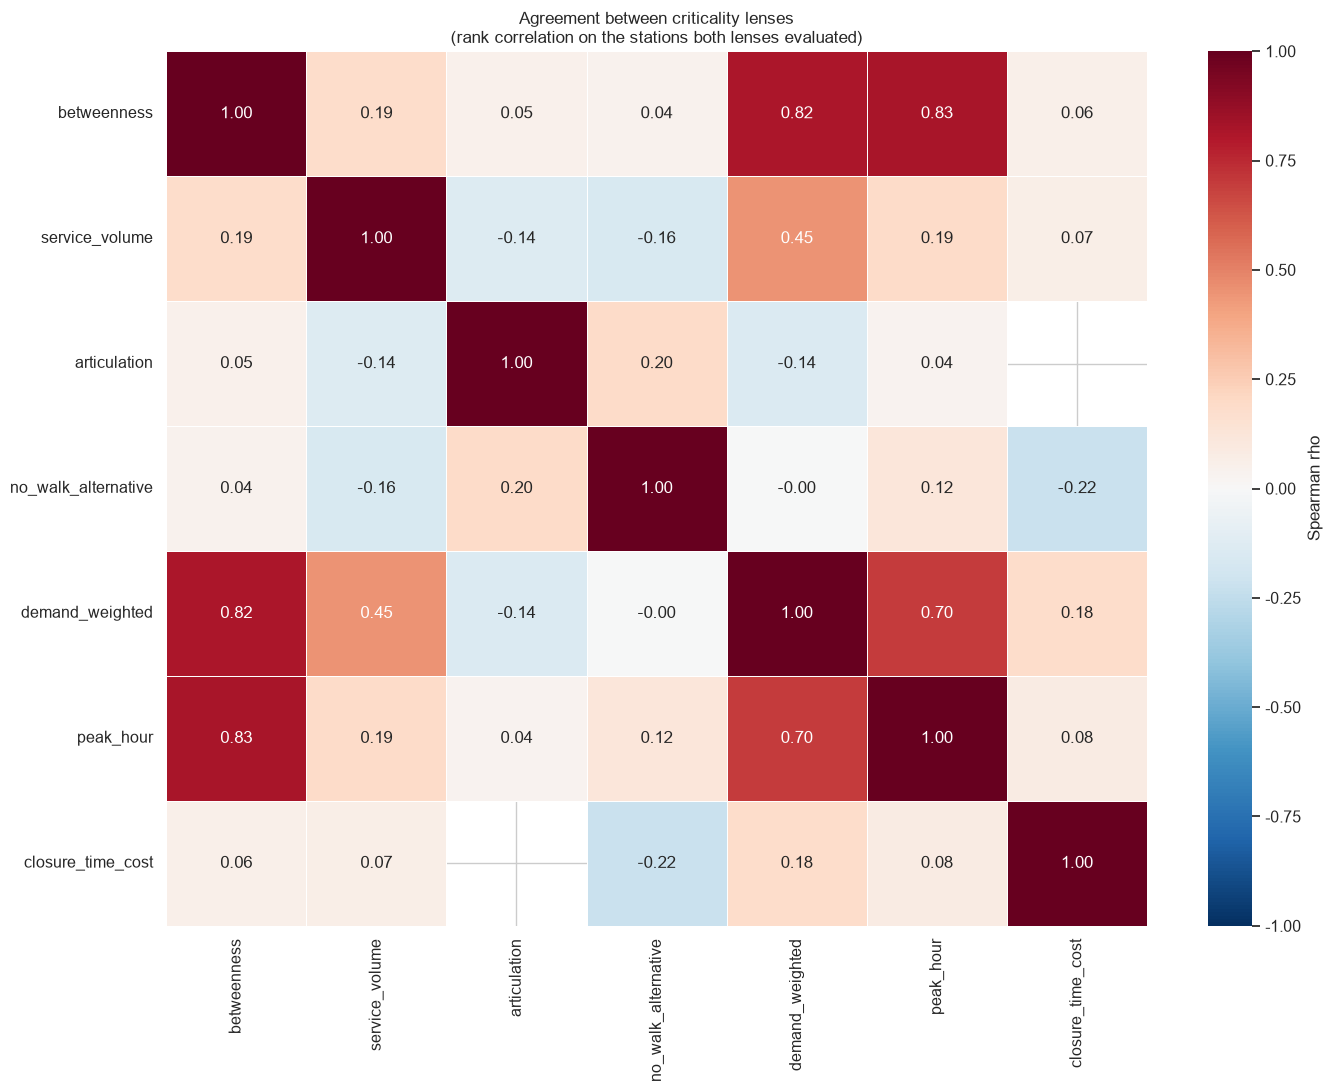

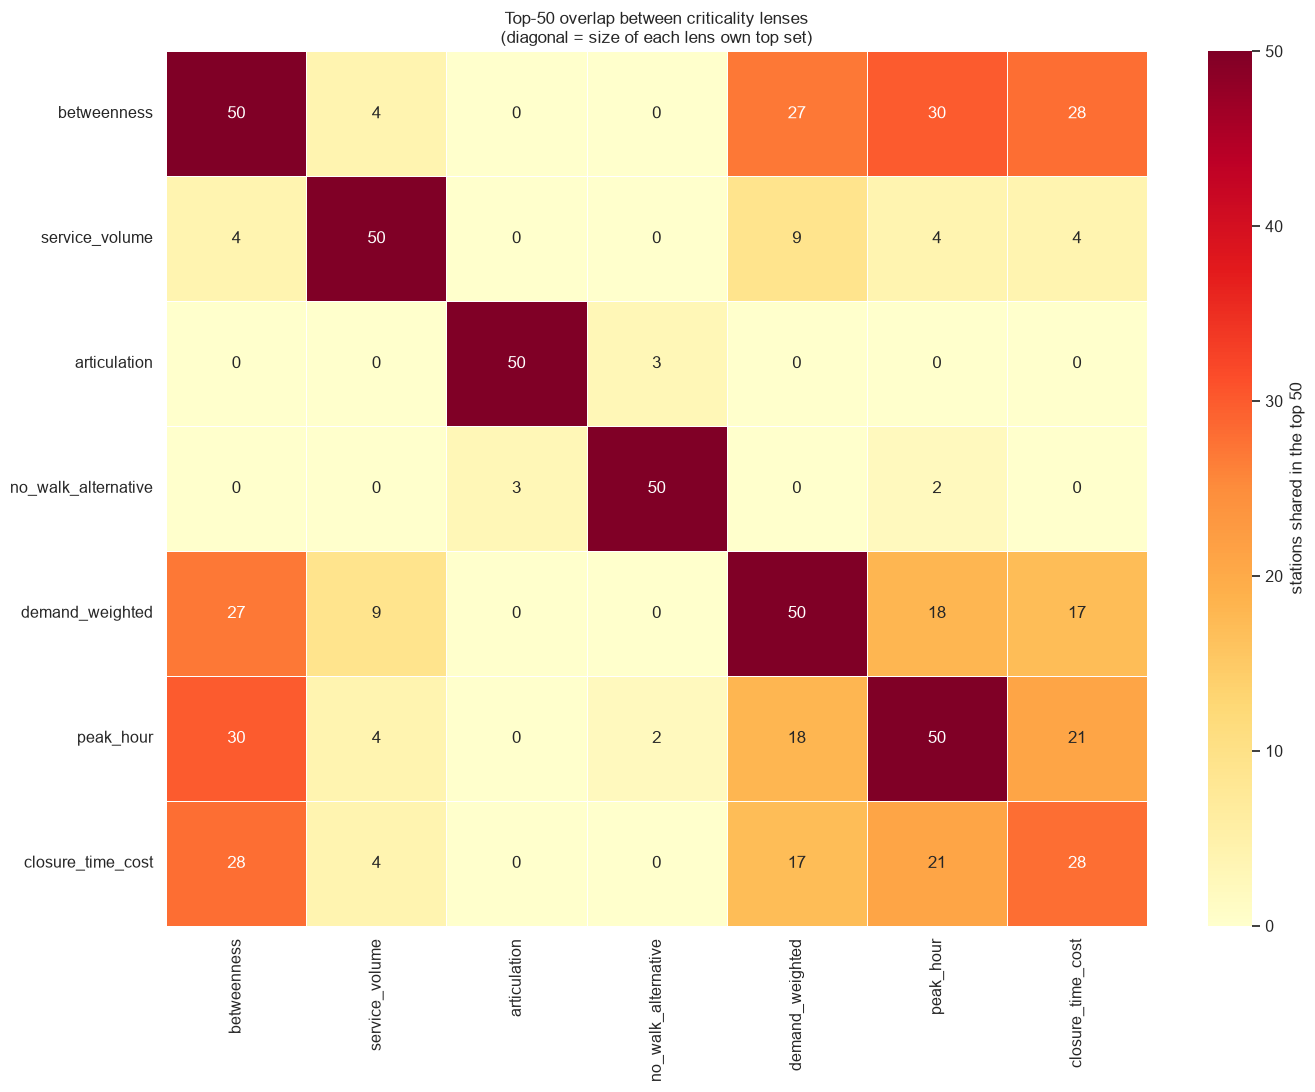

In [17]:
# --- Agreement heatmaps ----------------------------------------------------
rho_m = pd.DataFrame(np.nan, index=lens_names, columns=lens_names, dtype=float)
ovl_m = pd.DataFrame(0, index=lens_names, columns=lens_names, dtype=int)
for _, r in agreement.iterrows():
    a, b = r['lens_a'], r['lens_b']
    rho_m.loc[a, b] = rho_m.loc[b, a] = r['spearman_rho']
    ovl_m.loc[a, b] = ovl_m.loc[b, a] = int(r['top50_overlap'])
for n in lens_names:
    rho_m.loc[n, n] = 1.0
    ovl_m.loc[n, n] = len(topk_sets[n])

fig, ax = plt.subplots(figsize=(1.6 * len(lens_names) + 3, 1.3 * len(lens_names) + 2))
sns.heatmap(rho_m, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, center=0,
            linewidths=0.5, cbar_kws={'label': 'Spearman rho'}, ax=ax)
ax.set_title('Agreement between criticality lenses\n'
             '(rank correlation on the stations both lenses evaluated)')
plt.tight_layout()
plt.savefig(FIGURES / 'lens_spearman_heatmap.png', dpi=FIG_DPI)
plt.show()

fig, ax = plt.subplots(figsize=(1.6 * len(lens_names) + 3, 1.3 * len(lens_names) + 2))
sns.heatmap(ovl_m, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': f'stations shared in the top {TOP_K}'}, ax=ax)
ax.set_title(f'Top-{TOP_K} overlap between criticality lenses\n'
             '(diagonal = size of each lens own top set)')
plt.tight_layout()
plt.savefig(FIGURES / 'lens_top_overlap_heatmap.png', dpi=FIG_DPI)
plt.show()

## 18. Build one profile row per station

We pivot lens percentiles and ranks into a wide station table, then add:

- `n_lenses_evaluated`, the coverage denominator;
- `n_lenses_topk`, the number of available lenses placing the station in their top 50;
- `consensus_mean_pct`, the mean percentile only across lenses that evaluated it;
- `reasons`, a readable list of the lens names and ranks that flagged it.

We sort primarily by the count of independent flags. The mean percentile is only a tie-breaker because a high average based on one narrow lens is not consensus.

In [18]:
# --- Wide per-station profile ----------------------------------------------
rank_wide = pd.concat([LENSES[n].set_index('stop_id')['rank'].rename(n)
                       for n in lens_names], axis=1)
pct_wide = pd.concat([LENSES[n].set_index('stop_id')['pct'].rename(n)
                      for n in lens_names], axis=1)
rank_wide.index.name = 'stop_id'
pct_wide.index.name = 'stop_id'
flags = rank_wide.le(TOP_K)          # NaN ranks compare False, matching the intended flag

prof = pd.DataFrame(index=pct_wide.index)
prof['n_lenses_evaluated'] = pct_wide.notna().sum(axis=1).astype(int)
prof['n_lenses_topk'] = flags.sum(axis=1).astype(int)
prof['consensus_mean_pct'] = pct_wide.mean(axis=1).round(4)
prof['lenses_topk'] = flags.apply(
    lambda row: ';'.join([c for c in flags.columns if bool(row[c])]), axis=1)
prof = prof.reset_index()

prof = prof.merge(rank_wide.add_prefix('rank_').reset_index(), on='stop_id', how='left')
prof = prof.merge(pct_wide.add_prefix('pct_').reset_index(), on='stop_id', how='left')
prof = prof.merge(spine, on='stop_id', how='left')


def reason_text(row):
    """Human-readable justification: which lenses flagged this station, and at what rank."""
    bits = [f'{n} (#{int(row["rank_" + n])})'
            for n in lens_names
            if pd.notna(row['rank_' + n]) and row['rank_' + n] <= TOP_K]
    return '; '.join(bits) if bits else 'in no lens top-' + str(TOP_K)


prof['reasons'] = prof.apply(reason_text, axis=1)
prof = prof.sort_values(['n_lenses_topk', 'consensus_mean_pct'],
                        ascending=[False, False]).reset_index(drop=True)
prof.to_csv(TABLES / 'station_lens_profile.csv', index=False, encoding='utf-8-sig')

dist = prof['n_lenses_topk'].value_counts().sort_index()
print('stations flagged by exactly k lenses:')
for k, v in dist.items():
    print(f'   k = {k}: {v:,} stations')
print(f'\nflagged by at least one lens: {int((prof["n_lenses_topk"] > 0).sum()):,}')
print(f'flagged by two or more lenses: {int((prof["n_lenses_topk"] >= 2).sum()):,}')

stations flagged by exactly k lenses:
   k = 0: 30,230 stations
   k = 1: 178 stations
   k = 2: 28 stations
   k = 3: 13 stations
   k = 4: 10 stations
   k = 5: 4 stations

flagged by at least one lens: 233
flagged by two or more lenses: 55


## 19. Count how many definitions flag each station

We plot the distribution of `n_lenses_topk` across the full station universe. This tells us whether agreement is concentrated in a small core or whether most flags come from one definition only. The current run also prints the number flagged at least once and at least twice.

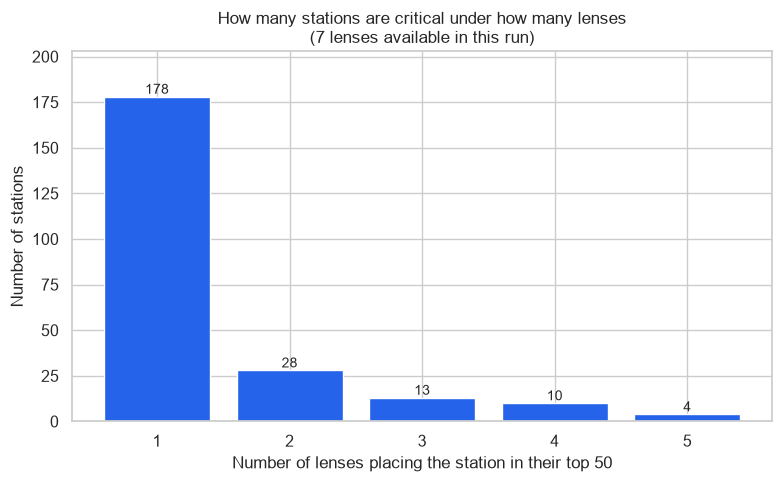

In [19]:
# --- Distribution of evidence across lenses --------------------------------
flagged = prof[prof['n_lenses_topk'] > 0]
counts = flagged['n_lenses_topk'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar([str(k) for k in counts.index], counts.to_numpy(), color='#2563eb')
for bar, val in zip(bars, counts.to_numpy()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{val:,}',
            ha='center', va='bottom', fontsize=10)
ax.set_xlabel(f'Number of lenses placing the station in their top {TOP_K}')
ax.set_ylabel('Number of stations')
ax.set_title(f'How many stations are critical under how many lenses\n'
             f'({len(lens_names)} lenses available in this run)')
ax.margins(y=0.14)
plt.tight_layout()
plt.savefig(FIGURES / 'stations_by_lens_count.png', dpi=FIG_DPI)
plt.show()

## 20. Export a limited shortlist

We keep stations evaluated by at least two lenses and flagged in at least one top 50, sort by number of top-50 flags and then mean percentile, and export the first `SHORTLIST_SIZE = 40`.

Every row includes the reason string and the individual lens ranks. This is a ranking of cross-lens evidence, not a direct investment score: it contains no failure probability, repair cost, passenger count, or intervention benefit.

In [20]:
# --- Final ranked shortlist ------------------------------------------------
eligible = prof[(prof['n_lenses_evaluated'] >= MIN_LENSES_FOR_SHORTLIST)
                & (prof['n_lenses_topk'] >= 1)].copy()
shortlist = (eligible.sort_values(['n_lenses_topk', 'consensus_mean_pct'],
                                  ascending=[False, False])
             .head(SHORTLIST_SIZE)
             .reset_index(drop=True))
shortlist.insert(0, 'shortlist_rank', np.arange(1, len(shortlist) + 1))

front = ['shortlist_rank', 'stop_id', 'stop_name', 'region', 'lat', 'lon',
         'n_lenses_topk', 'n_lenses_evaluated', 'consensus_mean_pct', 'reasons']
front = [c for c in front if c in shortlist.columns]
rest = [c for c in shortlist.columns if c not in front]
shortlist = shortlist[front + rest]
shortlist.to_csv(TABLES / 'critical_station_shortlist.csv', index=False, encoding='utf-8-sig')

print(f'{len(eligible):,} stations were eligible; the top {len(shortlist)} are exported.')
shortlist[['shortlist_rank', 'stop_name', 'region', 'n_lenses_topk',
           'consensus_mean_pct', 'reasons']].head(TOP_N_FIG)

233 stations were eligible; the top 40 are exported.


,shortlist_rank,stop_name,region,n_lenses_topk,consensus_mean_pct,reasons
0,1,מחלף חמד,Jerusalem,5,0.8843,betweenness (#5); service_volume (#48); demand...
1,2,מחלף גבעת שמואל/כביש 4,Center,5,0.8340,betweenness (#17); service_volume (#22); deman...
2,3,מחלף חמד,Jerusalem,5,0.8079,betweenness (#2); service_volume (#49); demand...
3,4,ויצמן/גבעת שאול,Jerusalem,5,0.7186,betweenness (#28); service_volume (#37); deman...
4,5,מחלף גהה/דרך ז'בוטינסקי,Center,4,0.8998,betweenness (#21); demand_weighted (#18); peak...
5,6,מחלף קסם,Center,4,0.8594,betweenness (#8); demand_weighted (#26); peak_...
6,7,דרך האר''י/ כביש 375,Jerusalem,4,0.8572,betweenness (#4); demand_weighted (#2); peak_h...
7,8,מחלף קסם,Center,4,0.8274,betweenness (#18); demand_weighted (#47); peak...
8,9,בן גוריון/שערי ירושלים,Jerusalem,4,0.8182,betweenness (#11); demand_weighted (#21); peak...
9,10,מחלף קמה לצפון,South,4,0.8117,betweenness (#3); demand_weighted (#6); peak_h...


## 21. Show the shortlist's full lens profile

The heatmap has shortlist stations as rows and lens percentiles as columns. Dark cells indicate a high within-lens rank; gray means the lens never evaluated that station, not a low score. We append station IDs to the Hebrew names so duplicate names remain distinguishable.

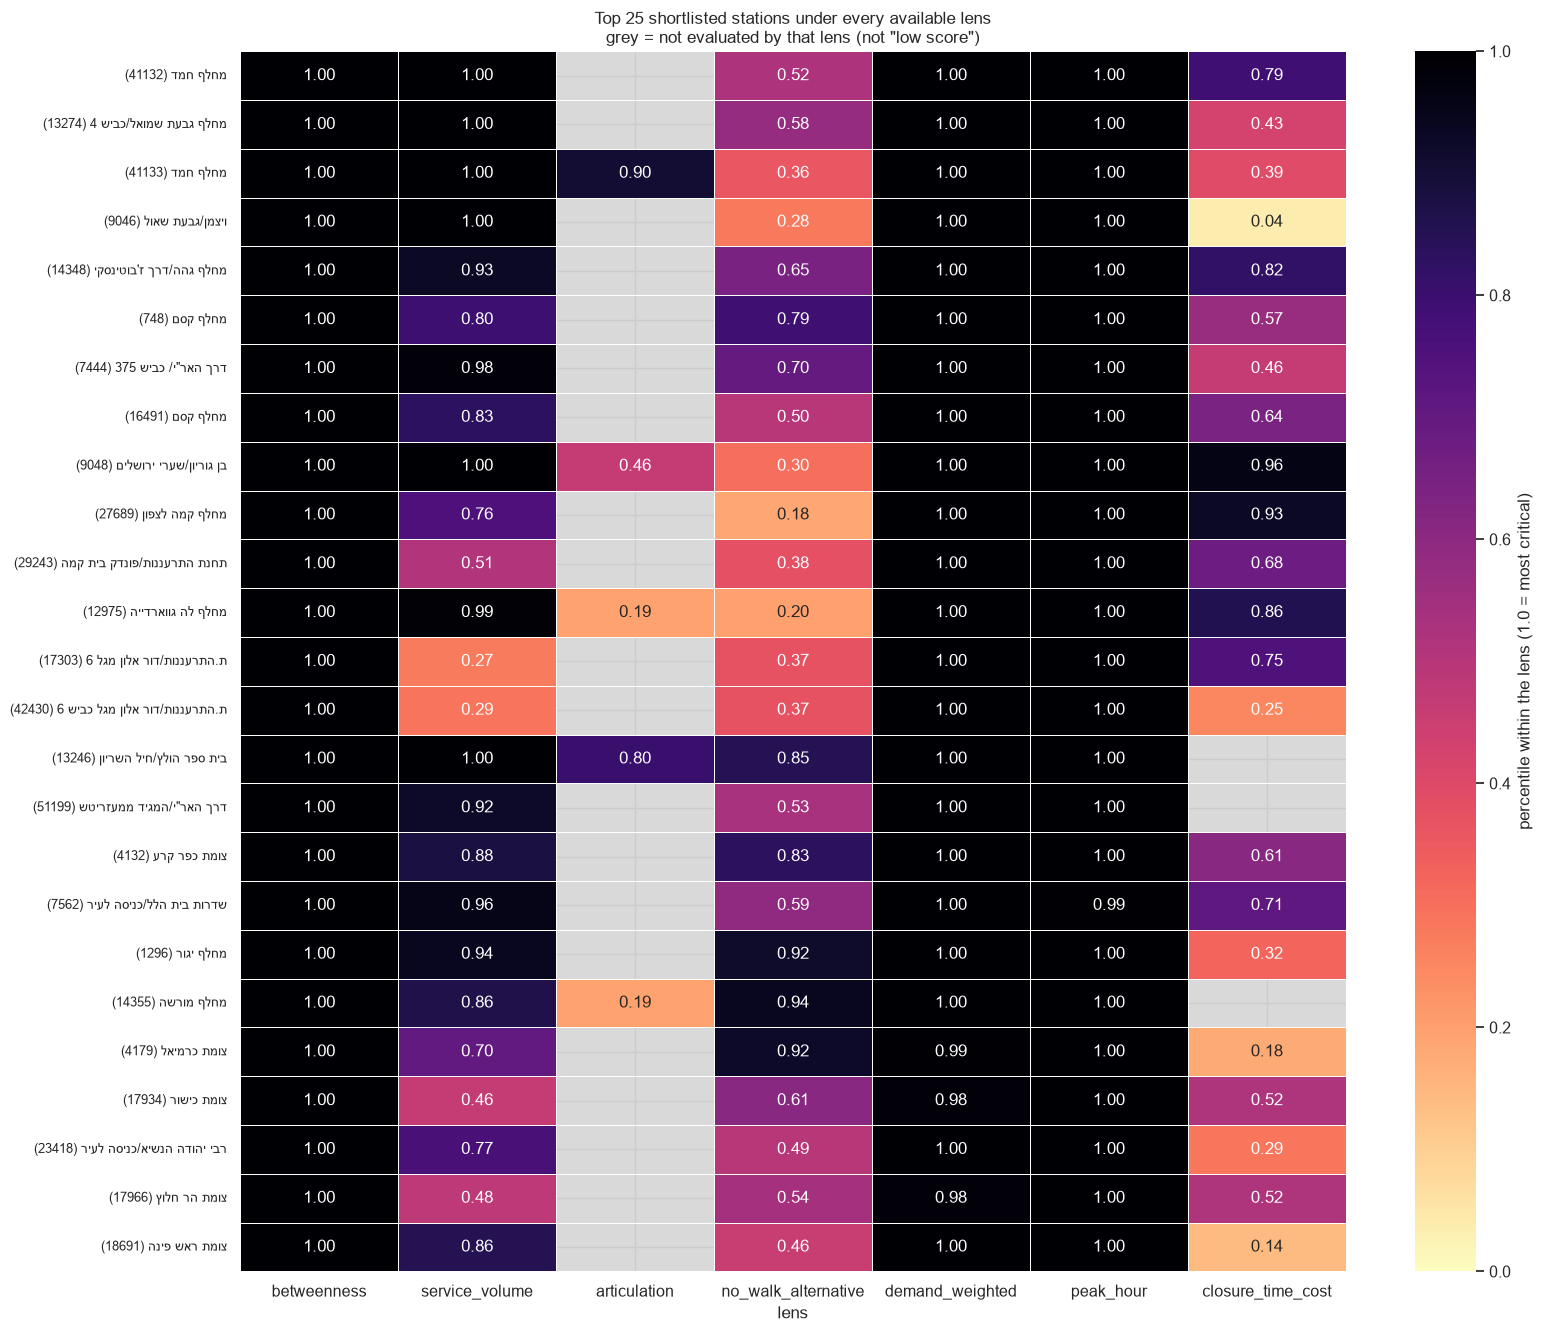

In [21]:
# --- Shortlist profile heatmap ---------------------------------------------
top_rows = shortlist.head(TOP_N_FIG).copy()
pct_cols = ['pct_' + n for n in lens_names]
mat = top_rows[pct_cols].astype(float)
mat.columns = lens_names
mat.index = [f'{name} ({sid})' for name, sid
             in zip(top_rows['stop_name'].fillna('?'), top_rows['stop_id'])]

fig, ax = plt.subplots(figsize=(1.5 * len(lens_names) + 6, 0.42 * len(mat) + 3))
sns.heatmap(mat, annot=True, fmt='.2f', cmap='magma_r', vmin=0, vmax=1,
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'percentile within the lens (1.0 = most critical)'},
            mask=mat.isna(), ax=ax)
ax.set_facecolor('#d9d9d9')          # grey = the lens never evaluated this station
ax.set_title(f'Top {len(mat)} shortlisted stations under every available lens\n'
             'grey = not evaluated by that lens (not "low score")')
ax.set_xlabel('lens')
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / 'shortlist_lens_profile.png', dpi=FIG_DPI)
plt.show()

## 22. Map the shortlist

We plot the full station cloud in the background and place shortlist stations on top, using size and color for the number of lens top-50 flags. We correct the plain longitude/latitude aspect ratio with the mean latitude. The regional count printed below the map helps us see whether the synthesis is dominated by the dense center or also includes northern, southern, and Jerusalem corridors.

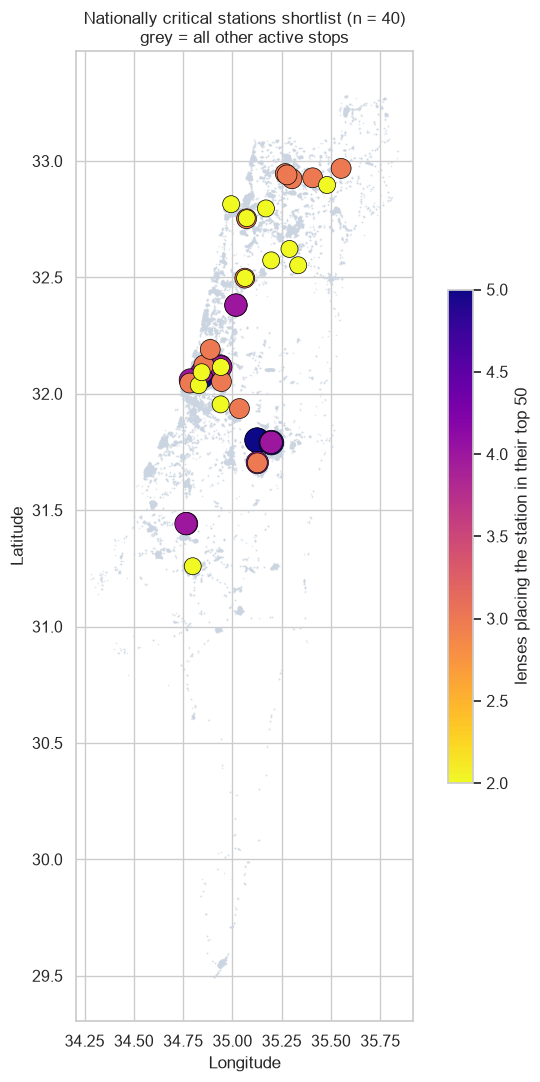

shortlist by region:
region
Center       18
North        13
Jerusalem     6
South         3


In [22]:
# --- Map of the shortlist --------------------------------------------------
base = spine.dropna(subset=['lat', 'lon'])
pts = shortlist.dropna(subset=['lat', 'lon'])

fig, ax = plt.subplots(figsize=(8, 11))
ax.scatter(base['lon'], base['lat'], s=1.5, color='#cbd5e1', alpha=0.55, linewidths=0)
if len(pts):
    sc = ax.scatter(pts['lon'], pts['lat'], c=pts['n_lenses_topk'],
                    s=40 + 55 * pts['n_lenses_topk'], cmap='plasma_r',
                    edgecolor='black', linewidths=0.5, zorder=3)
    cbar = plt.colorbar(sc, ax=ax, fraction=0.035)
    cbar.set_label(f'lenses placing the station in their top {TOP_K}')
    ax.set_aspect(1 / np.cos(np.deg2rad(float(base['lat'].mean()))))
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Nationally critical stations shortlist (n = {len(pts)})\n'
             'grey = all other active stops')
plt.tight_layout()
plt.savefig(FIGURES / 'shortlist_map.png', dpi=FIG_DPI)
plt.show()

if 'region' in shortlist.columns:
    print('shortlist by region:')
    print(shortlist['region'].fillna('Unknown').value_counts().to_string())

## 23. Separate stations supported by exactly one lens

We define a lens-specific station as one that appears in exactly one top 50 while at least one other lens also evaluated it and did not flag it. This excludes stations visible to only one narrow lens, where we would have no actual disagreement.

We save the rows and count them by their sole lens. These are not automatically errors or meaningless byproducts; they are definition-specific candidates. The table tells us which metric needs to be named explicitly if we discuss one of them.

178 stations are flagged by exactly one lens while at least one other lens evaluated them and did not flag them.


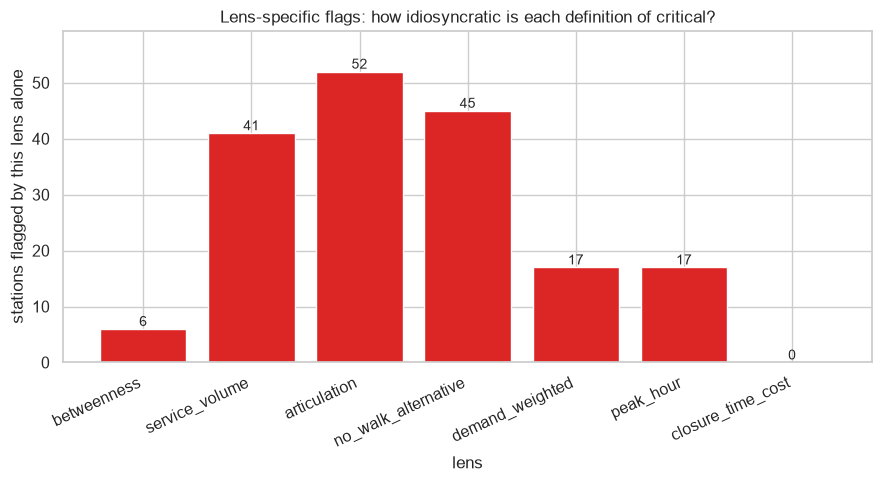

,stop_id,stop_name,region,lat,lon,only_lens,n_lenses_evaluated,consensus_mean_pct,reasons
106,11221,קיבוץ מעלה החמישה,Jerusalem,31.818536,35.111899,articulation,6,0.8616,articulation (#9)
114,7935,טורקיז/ענבר,Center,31.962056,35.065781,articulation,6,0.8414,articulation (#4)
135,39840,טבעת דרומית,Center,32.257872,35.004816,articulation,5,0.7955,articulation (#23)
138,11227,צומת אורה,Jerusalem,31.757147,35.159936,articulation,6,0.7924,articulation (#9)
141,15949,מחמוד דרוויש/אלבוחארי,Center,32.257506,35.006394,articulation,6,0.7837,articulation (#23)
143,20128,איבטין טחנת קמח,North,32.763357,35.106344,articulation,6,0.7780,articulation (#9)
144,35529,כפר הנשיא,North,32.974481,35.603560,articulation,5,0.7773,articulation (#14)
146,17861,אדמית מרכז,North,33.079481,35.211363,articulation,6,0.7690,articulation (#6)
147,34581,'איתמר א,Center,32.175204,35.308726,articulation,5,0.7688,articulation (#23)
158,50832,האלון/הרימון,North,32.619844,35.074935,articulation,6,0.7363,articulation (#8)


In [23]:
# --- Stations flagged by exactly one lens ----------------------------------
single = prof[(prof['n_lenses_topk'] == 1)
              & (prof['n_lenses_evaluated'] >= 2)].copy()
single['only_lens'] = single['lenses_topk']
single_out = single[['stop_id', 'stop_name', 'region', 'lat', 'lon', 'only_lens',
                     'n_lenses_evaluated', 'consensus_mean_pct', 'reasons']]
single_out = single_out.sort_values(['only_lens', 'consensus_mean_pct'],
                                    ascending=[True, False])
single_out.to_csv(TABLES / 'lens_specific_stations.csv', index=False, encoding='utf-8-sig')

per_lens = single['only_lens'].value_counts().reindex(lens_names).fillna(0).astype(int)
print(f'{len(single):,} stations are flagged by exactly one lens while at least one '
      'other lens evaluated them and did not flag them.')

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(per_lens.index.astype(str), per_lens.to_numpy(), color='#dc2626')
for bar, val in zip(bars, per_lens.to_numpy()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{val:,}',
            ha='center', va='bottom', fontsize=10)
ax.set_xlabel('lens')
ax.set_ylabel('stations flagged by this lens alone')
ax.set_title('Lens-specific flags: how idiosyncratic is each definition of critical?')
plt.setp(ax.get_xticklabels(), rotation=25, ha='right')
ax.margins(y=0.14)
plt.tight_layout()
plt.savefig(FIGURES / 'lens_specific_counts.png', dpi=FIG_DPI)
plt.show()

single_out.head(15)

## 24. Save a compact summary of this run

We write the universe size, available and missing lenses, coverage, pairwise agreement range, top-50 overlaps, flag counts, shortlist size, articulation method, and unreachable penalty to JSON. We include the run settings because a different candidate set, top-K cutoff, or missing lens changes what “consensus” means.

In [24]:
# --- Summary JSON ----------------------------------------------------------
rho_vals = agreement['spearman_rho'].dropna()
top_rows_json = shortlist.head(10)[['shortlist_rank', 'stop_id', 'stop_name',
                                    'n_lenses_topk', 'consensus_mean_pct', 'reasons']]

summary = {
    'stations_in_universe': int(len(spine)),
    'top_k_definition': int(TOP_K),
    'lenses_available': lens_names,
    'lenses_missing': [{'lens': a, 'needs': b, 'missing': c} for a, b, c in MISSING_LENSES],
    'lens_coverage': {n: LENS_META[n]['stations_evaluated'] for n in lens_names},
    'lens_pairs_compared': int(len(agreement)),
    'spearman_rho_mean': round(float(rho_vals.mean()), 4) if len(rho_vals) else None,
    'spearman_rho_min': round(float(rho_vals.min()), 4) if len(rho_vals) else None,
    'spearman_rho_max': round(float(rho_vals.max()), 4) if len(rho_vals) else None,
    'top_k_overlap_mean': round(float(agreement['top50_overlap'].mean()), 2),
    'stations_flagged_by_any_lens': int((prof['n_lenses_topk'] > 0).sum()),
    'stations_flagged_by_two_or_more': int((prof['n_lenses_topk'] >= 2).sum()),
    'stations_flagged_by_three_or_more': int((prof['n_lenses_topk'] >= 3).sum()),
    'stations_flagged_by_exactly_one': int(len(single)),
    'max_lenses_agreeing_on_one_station': int(prof['n_lenses_topk'].max()),
    'shortlist_size': int(len(shortlist)),
    'unreachable_penalty_seconds': int(UNREACHABLE_PENALTY_SECONDS),
    'articulation_severity_exact': bool(AP_SEVERITY_EXACT),
    'shortlist_top10': top_rows_json.to_dict(orient='records'),
}

with open(STAGE / 'lens_synthesis_summary.json', 'w', encoding='utf-8') as fh:
    json.dump(summary, fh, ensure_ascii=False, indent=2)

print(json.dumps({k: v for k, v in summary.items() if k != 'shortlist_top10'},
                 ensure_ascii=False, indent=2))
print('\nfiles written under', STAGE)
for p in sorted(STAGE.rglob('*')):
    if p.is_file():
        print('   ', p.relative_to(STAGE))

{
  "stations_in_universe": 30463,
  "top_k_definition": 50,
  "lenses_available": [
    "betweenness",
    "service_volume",
    "articulation",
    "no_walk_alternative",
    "demand_weighted",
    "peak_hour",
    "closure_time_cost"
  ],
  "lenses_missing": [],
  "lens_coverage": {
    "betweenness": 30463,
    "service_volume": 30463,
    "articulation": 900,
    "no_walk_alternative": 3047,
    "demand_weighted": 30463,
    "peak_hour": 30057,
    "closure_time_cost": 28
  },
  "lens_pairs_compared": 21,
  "spearman_rho_mean": 0.1665,
  "spearman_rho_min": -0.2242,
  "spearman_rho_max": 0.8254,
  "top_k_overlap_mean": 7.95,
  "stations_flagged_by_any_lens": 233,
  "stations_flagged_by_two_or_more": 55,
  "stations_flagged_by_three_or_more": 27,
  "stations_flagged_by_exactly_one": 178,
  "max_lenses_agreeing_on_one_station": 5,
  "shortlist_size": 40,
  "unreachable_penalty_seconds": 3600,
  "articulation_severity_exact": true
}

files written under /Users/seanfourman/Desktop/isr

## Conclusions

Here is what the current seven-lens run shows:

1. **Agreement is generally low.** Across 21 lens pairs, mean Spearman rho is `0.2096`, ranging from `-0.1582` to `0.8232`. The mean top-50 overlap is 8.1 stations, or 16.2% of a 50-station list.

2. **Full-day betweenness agrees most with related centrality variants, not with service volume.** Its rho with peak-hour betweenness is `0.8232` with 31 shared top-50 stations, and with the demand-weighted ranking it is `0.8163` with 27 shared stations. By contrast, betweenness versus scheduled service volume has rho `0.1868` and only four shared top-50 stations.

3. **Cut-vertex severity is a different signal again.** Betweenness versus articulation severity has rho `0.0480` and no shared top-50 station; service volume versus articulation severity has rho `-0.1390` and no shared top-50 station. Among the 900 cut vertices, the median removal strands two stations and the worst strands 39, so being a cut vertex does not automatically mean national-scale damage.

4. **Most top-50 flags are definition-specific.** In total, 231 stations appear in at least one lens's top 50. Of those, 171 (74.0%) appear under exactly one lens, 60 under at least two, and 26 under at least three. No station reaches all seven; the maximum is five lenses, reached by four stations.

5. **There is still a small cross-lens core.** The exported 40-row shortlist is led by the two Hamad Interchange stop IDs, Givat Shmuel Interchange/Route 4, and Weizmann/Givat Shaul, each flagged by five lenses. The map contains 19 Center, 11 North, six Jerusalem, and four South stations, so it is center-heavy but not center-only.

6. **Coverage limits every comparison.** Betweenness, service volume, and demand weighting cover all 30,463 stations; peak hour covers 30,057; walking alternatives 3,047; articulation severity 900; closure cost only 30. The walking test finds only 56 of its 3,047 preselected stations beyond the isolation cutoff, not a majority. A high overlap involving the 30-station closure lens is partly a consequence of the candidate selection and should not be treated like an independent full-network confirmation.

Our practical takeaway is to keep the definition attached to every critical-station claim. The shortlist is useful because several measures independently point to those stations, but the 171 single-lens rows are also useful when we care about that specific failure mode. None of this includes actual ridership, failure probability, repair cost, or a functional walking substitute, so it is a structured prioritization aid rather than a final decision rule.